In [45]:


import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [46]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

In [47]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [48]:
df.shape


(2640, 12)

In [49]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [51]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [52]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [53]:
df.columns.tolist()

['Year',
 'Month',
 'Region',
 'Model',
 'Estimated_Deliveries',
 'Production_Units',
 'Avg_Price_USD',
 'Battery_Capacity_kWh',
 'Range_km',
 'CO2_Saved_tons',
 'Source_Type',
 'Charging_Stations']

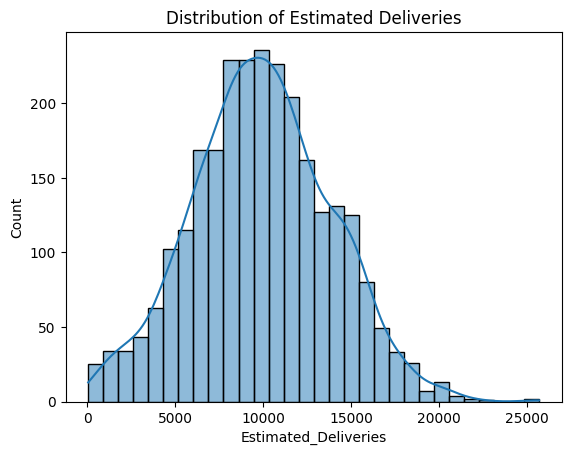

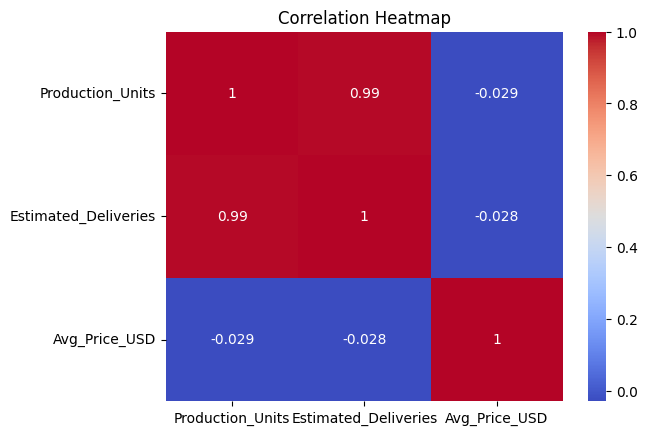

In [54]:
# Distr..  deliveries
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title('Distribution of Estimated Deliveries')
plt.show()

#heatmap
sns.heatmap(df[['Production_Units','Estimated_Deliveries','Avg_Price_USD']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

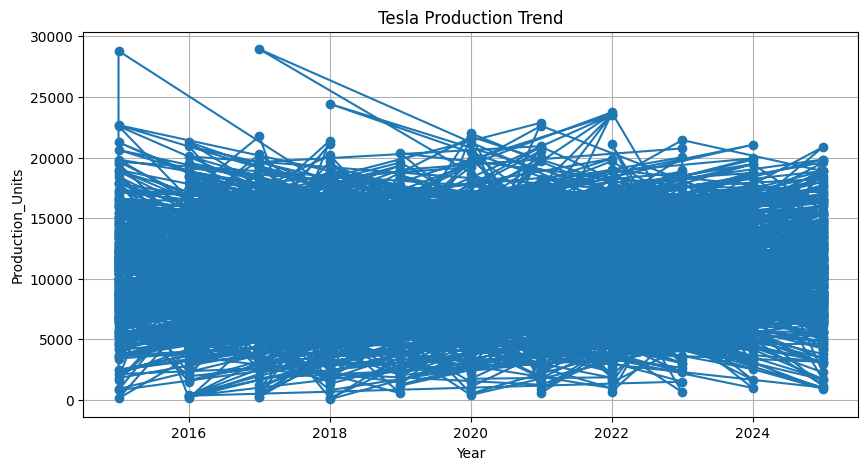

In [55]:
plt.figure(figsize = (10,5))

plt.plot(df['Year'],
        df['Production_Units'], marker = 'o')

plt.title('Tesla Production Trend')
plt.xlabel('Year')
plt.ylabel('Production_Units')


plt.grid(True)
plt.show()

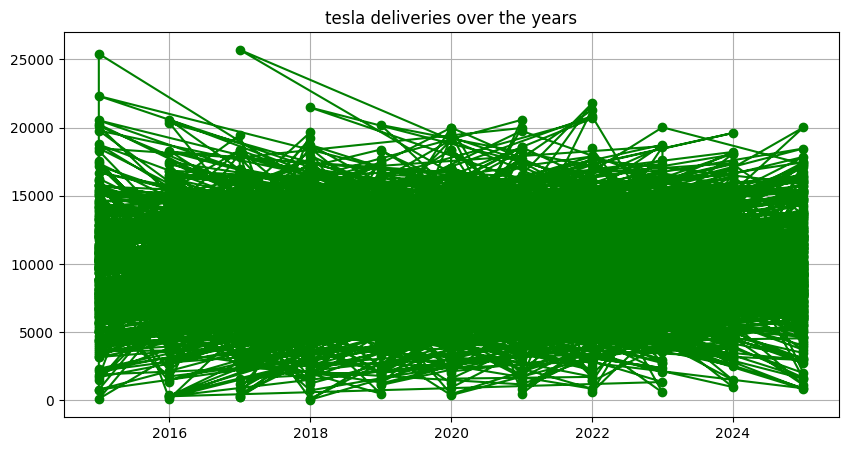

In [56]:
plt.figure(figsize =(10,5))

plt.plot(df['Year'], df['Estimated_Deliveries'], marker ='o', color = 'green')

plt.title('tesla deliveries over the years')


plt.grid(True)

plt.show()

both production and deliveries increased significantly after 2019, showing Tesla's rapid expansion in the electic vehicle industry.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score

In [58]:
x = df[['Production_Units']]
y= df['Estimated_Deliveries']

In [59]:
x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size = 0.2,
    random_state =42
)

In [60]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

X_train shape: (2112, 1)
X_test shape: (528, 1)


In [62]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [63]:
prediction = model.predict(x_test)

In [64]:
from sklearn.metrics import mean_squared_error

print("MAE  :", mean_absolute_error(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2   :", r2_score(y_test, prediction))

MAE  : 338.0775063695904
RMSE : 415.1175882512561
R2   : 0.9884396027684101


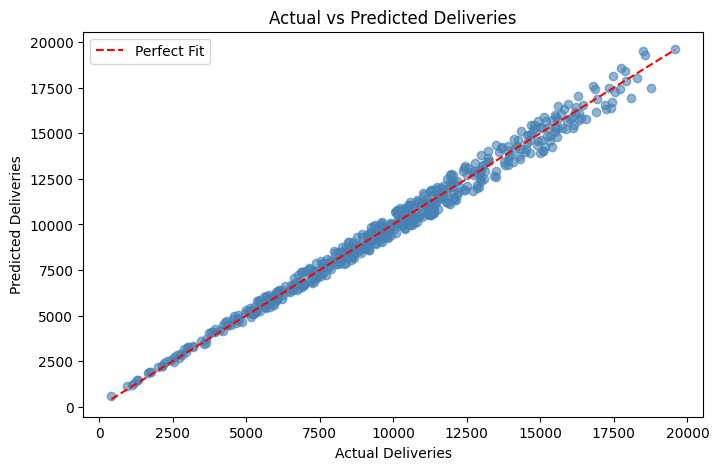

In [65]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, prediction, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')  # diagonal line
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.legend()
plt.show()

## Conclusion

The Linear Regression model achieved an R² score of [0.9884396027684101], 
meaning Production Units explains [98.84]% of variance in Deliveries.
The low MAE confirms the model predicts deliveries with reasonable accuracy.